In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

%matplotlib inline

In [2]:
df = pd.read_csv("C:/Users/adaml/OneDrive/Documents/Data Projects/9 Projects for ITonlinelearning portfolio/National_River_Toxin_Dataset_1.csv")
df.head(10)

,Date,River_System,pH_Level,Temperature,Lead,Mercury,Arsenic,Nitrates,Phosphates,Dissolved_Oxygen
0,2018-01-01,Amazon,7.030015,19.136212,2.500401,0.465454,3.578886,11.627614,0.522167,7.830196
1,2018-01-01,Nile,7.421766,21.406824,3.469443,0.859716,5.352155,10.538171,0.510465,8.130328
2,2018-01-01,Yangtze,7.133612,18.419902,3.806935,0.824085,5.277814,7.865033,0.585096,8.120874
3,2018-01-01,Mississippi,7.863001,18.014871,3.438131,0.500597,3.473881,11.143068,0.438248,6.853816
4,2018-01-01,Danube,7.527686,16.622289,2.188210,0.424178,2.454209,8.043467,0.422244,8.197925
5,2018-01-08,Amazon,6.816453,20.009290,2.317695,0.468534,2.779205,14.375101,NaN,8.801352
6,2018-01-08,Nile,7.713234,19.385417,3.281072,NaN,2.969543,8.043222,0.400075,7.887773
7,2018-01-08,Yangtze,6.997987,17.460123,5.077893,0.668969,6.103828,9.058403,0.667304,6.697805
8,2018-01-08,Mississippi,8.053054,20.636471,4.150143,0.629782,3.154285,8.761829,0.562562,8.981253
9,2018-01-08,Danube,7.552935,22.521190,2.779919,0.314452,2.232550,10.508599,0.534827,10.050782


In [3]:
df.describe()

,pH_Level,Temperature,Lead,Mercury,Arsenic,Nitrates,Phosphates,Dissolved_Oxygen
count,1278.000000,1278.000000,1285.000000,1278.000000,1279.000000,1265.000000,1282.000000,1284.000000
mean,7.353247,20.041668,3.011035,0.596108,3.597916,10.038789,0.497162,8.023795
std,0.349114,4.063638,0.874431,0.175150,0.992052,2.096641,0.106304,1.064190
min,6.465087,9.891618,0.551349,0.157117,1.485608,2.025075,0.144044,5.041394
25%,7.101324,16.813976,2.366298,0.462683,2.836160,8.701188,0.422006,7.269386
50%,7.339326,20.039121,3.000714,0.599186,3.511678,10.089112,0.497631,8.007448
75%,7.585733,23.358634,3.676560,0.734863,4.298946,11.391686,0.572888,8.740828
max,8.392902,30.749449,5.800963,1.057494,6.232902,16.547073,0.870007,11.228677


In [4]:
df.shape

(1305, 10)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1305 entries, 0 to 1304
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              1305 non-null   str    
 1   River_System      1305 non-null   str    
 2   pH_Level          1278 non-null   float64
 3   Temperature       1278 non-null   float64
 4   Lead              1285 non-null   float64
 5   Mercury           1278 non-null   float64
 6   Arsenic           1279 non-null   float64
 7   Nitrates          1265 non-null   float64
 8   Phosphates        1282 non-null   float64
 9   Dissolved_Oxygen  1284 non-null   float64
dtypes: float64(8), str(2)
memory usage: 102.1 KB


In [6]:
df.isnull().sum()

Date                 0
River_System         0
pH_Level            27
Temperature         27
Lead                20
Mercury             27
Arsenic             26
Nitrates            40
Phosphates          23
Dissolved_Oxygen    21
dtype: int64

In [7]:
#Fill missing values in numeric columns only
numeric_columns = df.select_dtypes(include=[np.number]).columns
df[numeric_columns]=df[numeric_columns].fillna(df[numeric_columns].mean())

In [8]:
#Converting data type to datetime object
df['Date']= pd.to_datetime(df['Date'])

In [9]:
#Average toxin levels for each river system
#My first attempt: average_toxin_level = df.groupby('River_System')[['Lead','Mercury','Arsenic','Nitrates','Phosphates','Dissolved_Oxygen']].mean().head(10)
average_toxin_levels = df[['Lead','Mercury','Arsenic']].mean()
print(f"Average Toxin Levels:\n{average_toxin_levels}")

Average Toxin Levels:
Lead       3.011035
Mercury    0.596108
Arsenic    3.597916
dtype: float64


Top Polluted Rivers by Lead Levels:
River_System
Yangtze        4.011200
Mississippi    3.478198
Nile           2.990203
Danube         2.544912
Amazon         2.030662
Name: Lead, dtype: float64


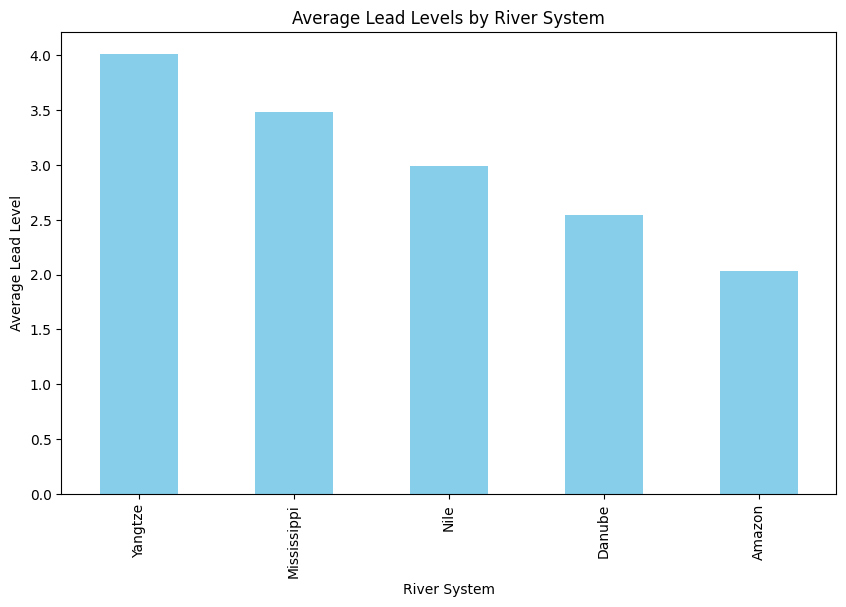

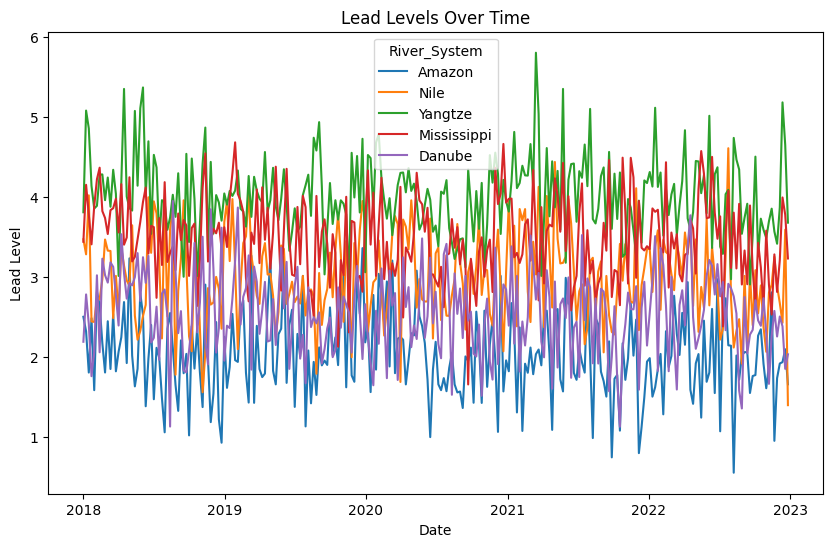

In [10]:
#Identify the top 5 most polluted river systems
top_polluted_rivers_lead = df.groupby('River_System')['Lead'].mean().sort_values(ascending=False)
print(f"Top Polluted Rivers by Lead Levels:\n{top_polluted_rivers_lead.head()}")

#Bar chart for average Lead levels per river
plt.figure(figsize=(10,6))
top_polluted_rivers_lead.plot(kind='bar', color='skyblue')
plt.title('Average Lead Levels by River System')
plt.xlabel('River System')
plt.ylabel('Average Lead Level')
plt.show()

#Line graph for toxin levels over time
plt.figure(figsize=(10,6))
sns.lineplot(x='Date', y='Lead', data=df, hue='River_System', errorbar=None)
errorbar=None
plt.title('Lead Levels Over Time')
plt.xlabel('Date')
plt.ylabel('Lead Level')
plt.show()

Top Polluted Rivers by Mercury Levels:
River_System
Yangtze        0.784567
Nile           0.706638
Mississippi    0.598506
Amazon         0.493555
Danube         0.397276
Name: Mercury, dtype: float64


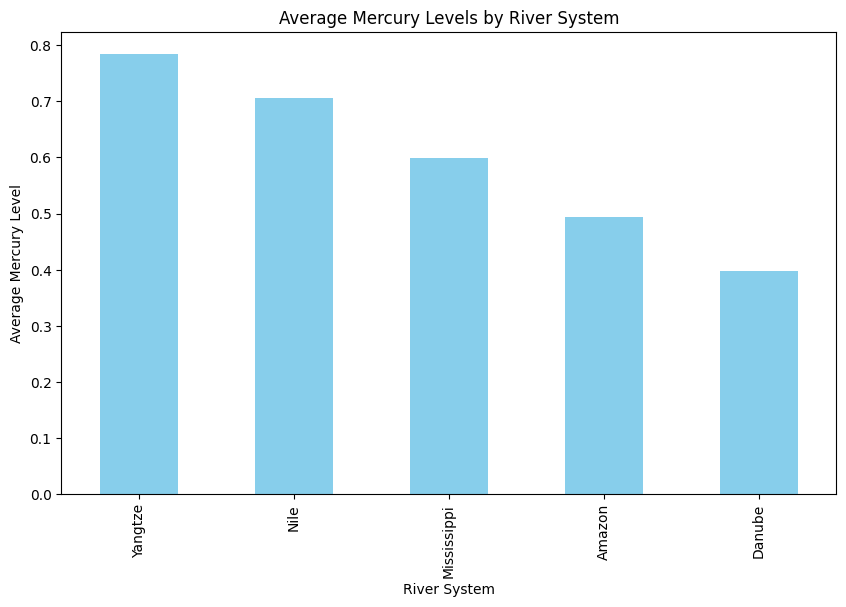

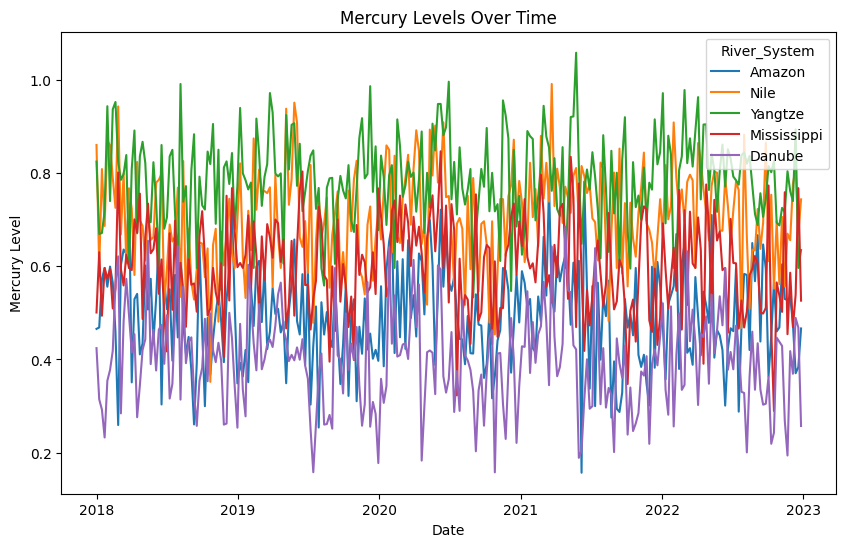

In [11]:
#Identify the top 5 most polluted river systems
top_polluted_rivers_merc = df.groupby('River_System')['Mercury'].mean().sort_values(ascending=False)
print(f"Top Polluted Rivers by Mercury Levels:\n{top_polluted_rivers_merc.head()}")

#Bar chart for average Lead levels per river
plt.figure(figsize=(10,6))
top_polluted_rivers_merc.plot(kind='bar', color='skyblue')
plt.title('Average Mercury Levels by River System')
plt.xlabel('River System')
plt.ylabel('Average Mercury Level')
plt.show()

#Line graph for toxin levels over time
plt.figure(figsize=(10,6))
sns.lineplot(x='Date', y='Mercury', data=df, hue='River_System', errorbar=None)
errorbar=None
plt.title('Mercury Levels Over Time')
plt.xlabel('Date')
plt.ylabel('Mercury Level')
plt.show()

Top Polluted Rivers by Mercury Levels:
River_System
Yangtze        4.969918
Nile           3.987877
Mississippi    3.492969
Amazon         3.021498
Danube         2.517318
Name: Arsenic, dtype: float64


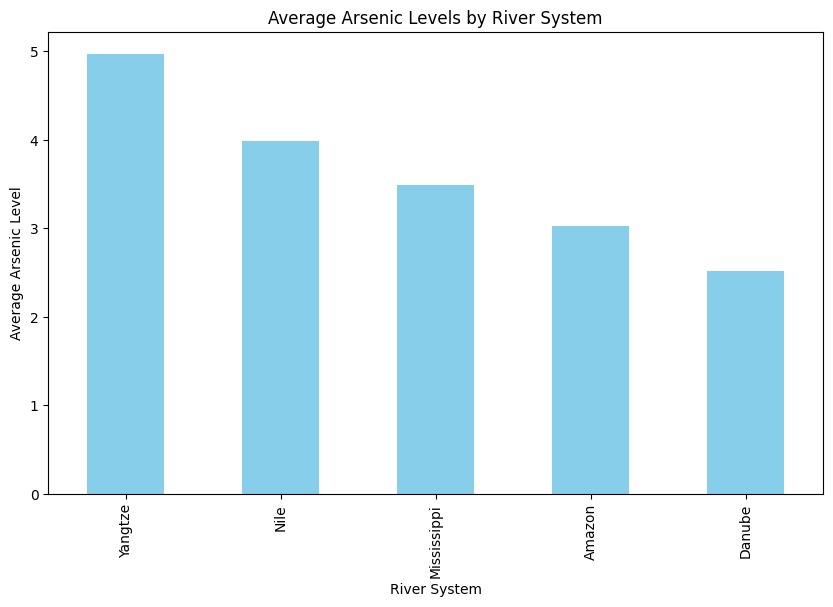

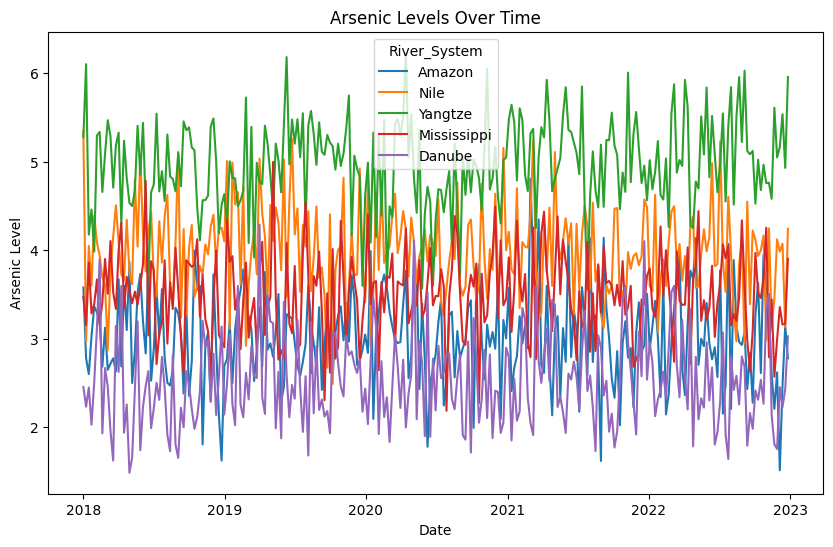

In [12]:
#Identify the top 5 most polluted river systems
top_polluted_rivers_ars = df.groupby('River_System')['Arsenic'].mean().sort_values(ascending=False)
print(f"Top Polluted Rivers by Mercury Levels:\n{top_polluted_rivers_ars.head()}")

#Bar chart for average Lead levels per river
plt.figure(figsize=(10,6))
top_polluted_rivers_ars.plot(kind='bar', color='skyblue')
plt.title('Average Arsenic Levels by River System')
plt.xlabel('River System')
plt.ylabel('Average Arsenic Level')
plt.show()

#Line graph for toxin levels over time
plt.figure(figsize=(10,6))
sns.lineplot(x='Date', y='Arsenic', data=df, hue='River_System', errorbar=None)
errorbar=None
plt.title('Arsenic Levels Over Time')
plt.xlabel('Date')
plt.ylabel('Arsenic Level')
plt.show()

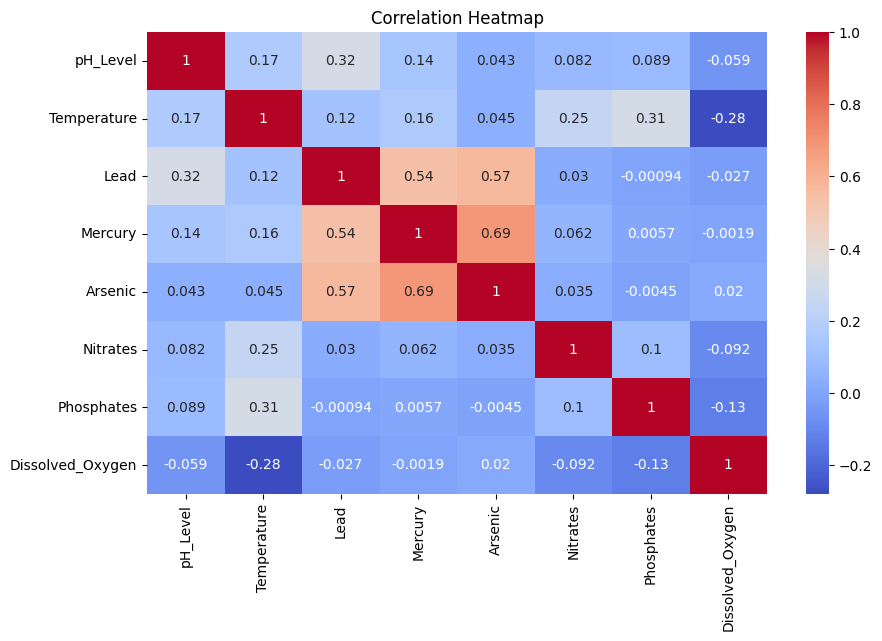

In [13]:
#Compute the correlation matrix using only numeric columns
corr_matrix=df[numeric_columns].corr()

#Heatmap for correlation between different parameters
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [14]:
#T-test between two river systems (e.g., Amazon and Nile)
amazon_data= df[df['River_System'] == 'Amazon']['Lead']
nile_data= df[df['River_System'] == 'Nile']['Lead']
t_stat, p_value = stats.ttest_ind(amazon_data, nile_data)

print(f"T-test between Amazon and Nile: T-statistic = {t_stat}, P-value = {p_value}")

T-test between Amazon and Nile: T-statistic = -20.23821779031797, P-value = 1.3375120881428719e-67


In [15]:
#Linear regression analysis for toxin levels and pH
x = df[['pH_Level']]
y = df['Lead']
model = LinearRegression()
model.fit(x, y)
print(f"Linear Regression Coefficients: {model.coef_}")
print(f"Linear Regression Intercept: {model.intercept_}")

Linear Regression Coefficients: [0.80294889]
Linear Regression Intercept: -2.893246694927761


##### Insights
- The Yangtze river system has the highest toxin levels overall having the highest average lead, mercury and arsenic levels.
- Toxin levels over time consistently spike up and down for all river systems, lacking a clear upward or downward trend. 
- There is a clear hierarchy between the rivers that persists throughout the entire five-year period.
- pH level generally has a weak positive correlation with the toxin concentrations. However, it's strongest relationship is with Lead (0.32). It suggests that as the pH level increases,  Lead concentrations tend to increase slightly as well.




##### Summary
- The Yangtze river system has the highest average lead, mercury and arsenic levels overall. This is closely followed by the Nile and Mississippi river, having the 2nd and 3rd highest average toxin levels. Danube river has the lowest average toxin level. It may be worth investigating what is causing the Yangtze river to consistently have the highest toxin levels.
- Toxin levels over time consistently spike up and down for all river systems, lacking a clear upward or downward trend. There's a lot of jagged peaks and valleys, but the overall average level for each river stays remarkably flat from 2018 through 2023. The trend suggests that toxin levels aren't necessarily rising, but are relatively stationary. 
- There is a clear hierarchy between the rivers that persists throughout the entire five-year period, with the Yangtze river being on top. Allocate immediate conservation funding and policy advocacy primarily towards the Yangtze river system with consideration to Nile/ Mississippi river systems.
- pH level generally has a weak positive correlation with the toxin concentrations. However, it's strongest relationship is with Lead (0.32). It suggests that as the pH level increases,  Lead concentrations tend to increase slightly as well. While pH levelmight have some influence over lead concentration, there are likely many other factors that affect the increasing levels of toxins in major systems. It may be worth collecting data on seasonal rainfall volume or proximity to industrial sites.
